# Few-Shot Segmentation: Euclidean vs Pontryagin — UAV Sugarcane

```
0. GPU check
1. Mount Google Drive
2. Configuration  ← EDIT paths here
3. Clone repo + install deps
4. Dataset
5. Smoke tests
6. HPO  (optional, ~30-60 min por modelo en T4)
7. Full training  (loads best_params.json automatically)
8. Analysis & results  (saved to Drive)
9. Download
```

> **Only cell 2 needs to be edited before running.**

## 0 · GPU check

In [1]:
import torch
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU            :', torch.cuda.get_device_name(0))
    print('VRAM (GB)      :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print('WARNING: no GPU — Runtime → Change runtime type → GPU')

CUDA available : True
GPU            : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM (GB)      : 4.0


## 1 · Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted.')
except ImportError:
    print('Not running on Colab — Drive mount skipped.')

Not running on Colab — Drive mount skipped.


## 2 · Configuration  ← EDIT THIS CELL

Set your Drive paths here.  
Everything else runs automatically.

In [3]:
import os
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    REPO_URL           = 'https://github.com/craljimenez/rr-pontryagin-embedded.git'
    REPO_DIR           = '/content/rr-pontryagin-embedded'
    DATA_ROOT          = '/content/drive/MyDrive/UAV_segmantation'
    DRIVE_RESULTS_ROOT = '/content/drive/MyDrive/fss_results'
else:
    # Walk UP from CWD until pyproject.toml is found — immune to kernel CWD quirks.
    _cwd = Path(os.getcwd()).resolve()
    _repo = next(
        (p for p in [_cwd, *_cwd.parents] if (p / 'pyproject.toml').exists()),
        None,
    )
    assert _repo is not None, f'pyproject.toml not found above {_cwd}'
    REPO_DIR           = str(_repo)
    DATA_ROOT          = str(_repo.parent / '002_rff_ss' / 'DATASETS' / 'UAV_segmantation')
    DRIVE_RESULTS_ROOT = str(_repo / 'experiments' / 'results' / 'fss_sugarcane')
    REPO_URL           = ''

K_SHOT = 1
os.makedirs(DRIVE_RESULTS_ROOT, exist_ok=True)
print(f'IN_COLAB           : {IN_COLAB}')
print(f'REPO_DIR           : {REPO_DIR}')
print(f'DATA_ROOT          : {DATA_ROOT}')
print(f'DRIVE_RESULTS_ROOT : {DRIVE_RESULTS_ROOT}')
print(f'K_SHOT             : {K_SHOT}')
print('Config OK.')


IN_COLAB           : False
REPO_DIR           : /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed
DATA_ROOT          : /home/craljimenez/Documents/PhD/002_rff_ss/DATASETS/UAV_segmantation
DRIVE_RESULTS_ROOT : /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane
K_SHOT             : 1
Config OK.


## 3 · Clone repo + install dependencies

In [4]:
import subprocess, sys
from pathlib import Path

if IN_COLAB:
    if not Path(REPO_DIR).exists():
        subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(['git', '-C', REPO_DIR, 'pull', '--rebase'], check=True)
    print(f'Repo at: {REPO_DIR}')
else:
    print(f'Local mode — repo already at {REPO_DIR}')
print('Done.')

Local mode — repo already at /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed
Done.


In [5]:
import importlib.util, subprocess, sys, os
from pathlib import Path

# Walk UP from CWD until pyproject.toml is found — works at any CWD depth.
_cwd  = Path(os.getcwd()).resolve()
_repo = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'pyproject.toml').exists()),
    None,
)
assert _repo is not None, f'pyproject.toml not found above {_cwd}'

def _ensure(import_name, *pip_args):
    if importlib.util.find_spec(import_name) is None:
        print(f'Installing {" ".join(str(a) for a in pip_args)} ...')
        subprocess.run(
            [sys.executable, '-m', 'pip', 'install', *pip_args, '-q'],
            check=True,
        )
        print(f'  {import_name} installed.')
    else:
        print(f'  {import_name} already installed — skipping.')

_ensure('prfe',      '-e', str(_repo))   # editable install
_ensure('skopt',     'scikit-optimize')
_ensure('PIL',       'Pillow')
_ensure('torchvision', 'torchvision')
print(f'Repo root : {_repo}')
print('Dependencies ready.')


  prfe already installed — skipping.
  skopt already installed — skipping.
  PIL already installed — skipping.
  torchvision already installed — skipping.
Repo root : /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed
Dependencies ready.


In [6]:
import sys, os, importlib, glob
from pathlib import Path

# Always re-derive REPO_DIR using src/prfe/ as unique marker.
_cwd  = Path(os.getcwd()).resolve()
_repo = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'src' / 'prfe').is_dir()),
    None,
)
assert _repo is not None, f'src/prfe/ not found above {_cwd}'
REPO_DIR = str(_repo)

_exp = str(_repo / 'experiments')
_src = str(_repo / 'src')
_venv_sp = sorted(glob.glob(str(_repo / '.venv' / 'lib' / 'python*' / 'site-packages')))
_venv_sp = _venv_sp[-1] if _venv_sp else None

# 1. Remove stale/relative entries first
sys.path = [
    p for p in sys.path
    if Path(p).is_absolute()
    and not any(k in p for k in ['rr-pontryagin', '003_pontriagyn', 'embebbed'])
]

# 2. Re-add the paths we need (venv must come AFTER cleanup, not before)
for p in filter(None, [_venv_sp, _exp, _src]):
    if p not in sys.path:
        sys.path.insert(0, p)

os.chdir(_exp)
importlib.invalidate_caches()

print(f'REPO_DIR : {REPO_DIR}')
print(f'CWD      : {os.getcwd()}')
print(f'venv sp  : {_venv_sp}')
print(f'sys.path : {sys.path[:5]}')

from configs.fss_sugarcane import AVAILABLE_MODELS
print('Imports OK. Available models:', AVAILABLE_MODELS)


REPO_DIR : /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed
CWD      : /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments
venv sp  : /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/.venv/lib/python3.12/site-packages
sys.path : ['/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/src', '/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments', '/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/.venv/lib/python3.12/site-packages', '/usr/lib/python312.zip', '/usr/lib/python3.12']
Imports OK. Available models: ('euclidean', 'pontryagin')


## 4 · Dataset

Verifica que `DATA_ROOT` contenga las splits `train/`, `valid/`, `test/` en formato YOLO polygon.  
Clase objetivo: **5 — Sugarcane**.

In [7]:
from pathlib import Path
from prfe.data.fss_dataset import EpisodicUAVDataset

DATA = Path(DATA_ROOT)
ok   = True
print('Split summary:')
for split in ('train', 'valid', 'test'):
    imgs = list((DATA / split / 'images').glob('*.jpg'))
    lbls = list((DATA / split / 'labels').glob('*.txt'))
    ds   = EpisodicUAVDataset(DATA, split, k_shot=K_SHOT, n_episodes=4, img_size=128)
    status = '✓' if imgs else '✗'
    if not imgs: ok = False
    print(f'  {status} {split:6s}: {len(imgs):3d} imgs  {len(lbls):3d} labels  '
          f'{len(ds.samples):3d} eligible (sugarcane)')

if not ok:
    raise RuntimeError('Dataset incompleto — revisa DATA_ROOT')
print('\nDataset OK.')

Split summary:
  ✓ train :  81 imgs   81 labels   49 eligible (sugarcane)
  ✓ valid :  30 imgs   30 labels   23 eligible (sugarcane)
  ✓ test  :  20 imgs   21 labels   13 eligible (sugarcane)

Dataset OK.


## 5 · Smoke tests  *(~2 min en CPU)*

Verifica dataset, forward pass, losses y gradientes con tensores 64×64.  
Deben completarse antes de lanzar HPO o entrenamiento.

In [8]:
import torch
from torch.utils.data import DataLoader
from prfe.data.fss_dataset import EpisodicUAVDataset
from prfe.models.fss import EuclideanFewShotSeg, PontryaginFewShotSeg
from prfe.losses.fss import EuclideanFSSLoss, PontryaginFSSLoss

# ── Test 1: dataset shapes ────────────────────────────────────────────────────
ds    = EpisodicUAVDataset(DATA, 'train', k_shot=K_SHOT, n_episodes=8, img_size=128)
batch = next(iter(DataLoader(ds, batch_size=4, num_workers=0)))
assert batch['support_imgs'].shape  == (4, K_SHOT, 3, 128, 128)
assert batch['query_mask'].shape    == (4, 128, 128)
print(f'✓ Dataset  support={tuple(batch["support_imgs"].shape)}  '
      f'query={tuple(batch["query_img"].shape)}')

# ── Test 2: forward pass ──────────────────────────────────────────────────────
B, K, H, W = 2, K_SHOT, 64, 64
si = torch.randn(B, K, 3, H, W)
sm = torch.randint(0, 2, (B, K, H, W)).float()
qi = torch.randn(B, 3, H, W)
qm = torch.randint(0, 2, (B, H, W)).float()

m_euc  = EuclideanFewShotSeg(base_ch=32, depth=3)
m_pont = PontryaginFewShotSeg(base_ch=32, depth=3, n_rff=16, n_srf=4, kappa=4)
assert m_euc(si, sm, qi).shape  == (B, H, W)
assert m_pont(si, sm, qi).shape == (B, H, W)
print(f'✓ Forward pass  euc={tuple(m_euc(si,sm,qi).shape)}  '
      f'pont={tuple(m_pont(si,sm,qi).shape)}')

# ── Test 3: losses & gradients ───────────────────────────────────────────────
l_euc  = EuclideanFSSLoss(bce_weight=0.5, pos_weight=5.0)
l_pont = PontryaginFSSLoss(J=m_pont.J, bce_weight=0.5, pos_weight=5.0,
                           lambda_cone=0.1, lambda_orth=0.05)
loss_e = m_euc.compute_loss(si, sm, qi, qm, l_euc);  loss_e.backward()
loss_p = m_pont.compute_loss(si, sm, qi, qm, l_pont); loss_p.backward()
assert torch.isfinite(loss_e) and torch.isfinite(loss_p)
print(f'✓ Losses  euc={loss_e.item():.4f}  pont={loss_p.item():.4f}')

print('\n✓ All smoke tests passed.')

✓ Dataset  support=(4, 1, 3, 128, 128)  query=(4, 3, 128, 128)
✓ Forward pass  euc=(2, 64, 64)  pont=(2, 64, 64)
✓ Losses  euc=1.7461  pont=1.8843

✓ All smoke tests passed.


## 6 · HPO  *(opcional — ~30-60 min por modelo en T4)*

Optimización bayesiana con `scikit-optimize` sobre val IoU.  
Salta automáticamente si `best_params.json` ya existe en Drive.  
Puedes saltar esta sección entera para entrenar con los hiperparámetros del config.

In [ ]:
import json
from pathlib import Path

for mt in AVAILABLE_MODELS:
    p = Path(DRIVE_RESULTS_ROOT) / f'{mt}_{K_SHOT}shot' / 'hpo' / 'best_params.json'
    if p.exists():
        d     = json.loads(p.read_text())
        score = d.get('_best_val_iou', float('nan'))
        print(f'  {mt:<12}  HPO done  —  best val_iou = {score:.4f}')
    else:
        print(f'  {mt:<12}  no HPO results yet')

### 6a · Euclidean

In [ ]:
from pathlib import Path
if not (Path(DRIVE_RESULTS_ROOT) / f'euclidean_{K_SHOT}shot' / 'hpo' / 'best_params.json').exists():
    !python {REPO_DIR}/experiments/tune_fss_sugarcane.py \
        --model        euclidean \
        --k-shot       {K_SHOT} \
        --n-calls      20 \
        --n-random     8 \
        --trial-epochs 8 \
        --data-root    "{DATA_ROOT}" \
        --results-dir  "{DRIVE_RESULTS_ROOT}"
else:
    print('euclidean HPO already done — skipping.')

### 6b · Pontryagin

In [ ]:
from pathlib import Path
if not (Path(DRIVE_RESULTS_ROOT) / f'pontryagin_{K_SHOT}shot' / 'hpo' / 'best_params.json').exists():
    !python {REPO_DIR}/experiments/tune_fss_sugarcane.py \
        --model        pontryagin \
        --k-shot       {K_SHOT} \
        --n-calls      30 \
        --n-random     10 \
        --trial-epochs 8 \
        --data-root    "{DATA_ROOT}" \
        --results-dir  "{DRIVE_RESULTS_ROOT}"
else:
    print('pontryagin HPO already done — skipping.')

## 7 · Entrenamiento completo

Carga `best_params.json` automáticamente si el HPO fue ejecutado.  
En caso contrario usa los valores por defecto del config.  
~20-30 min por modelo en T4 con `K_SHOT=1`.

In [ ]:
!python {REPO_DIR}/experiments/run_fss_sugarcane.py \
    --model       euclidean \
    --k-shot      {K_SHOT} \
    --data-root   "{DATA_ROOT}" \
    --results-dir "{DRIVE_RESULTS_ROOT}"

In [ ]:
!python {REPO_DIR}/experiments/run_fss_sugarcane.py \
    --model       pontryagin \
    --k-shot      {K_SHOT} \
    --data-root   "{DATA_ROOT}" \
    --results-dir "{DRIVE_RESULTS_ROOT}"

## 8 · Análisis y resultados

In [9]:
# ── Multi-run registry ────────────────────────────────────────────────────────
# Add / remove entries here to include runs in all comparison cells below.
RUNS = {
    'euclidean':  {'model_type': 'euclidean',  'trainable_rff': False},
    'pontryagin': {'model_type': 'pontryagin', 'trainable_rff': False},
}

def run_dir(label: str) -> str:
    r = RUNS[label]
    suffix = '_trainable' if r['trainable_rff'] else ''
    return f"{r['model_type']}_{K_SHOT}shot{suffix}"

COLORS = {
    'euclidean':  '#1f77b4',   # blue
    'pontryagin': '#ff7f0e',   # orange
}

import torch as _torch
DEVICE = 'cuda' if _torch.cuda.is_available() else 'cpu'
print('RUNS:', list(RUNS))
print('DEVICE:', DEVICE)


RUNS: ['euclidean', 'pontryagin']
DEVICE: cuda


### 8a · Tabla de métricas

In [10]:
import json
import pandas as pd
from pathlib import Path

rows = []
for label in RUNS:
    p = Path(DRIVE_RESULTS_ROOT) / run_dir(label) / 'metrics_test.json'
    if p.exists():
        d = json.loads(p.read_text())
        rows.append({
            'model':        label,
            'k_shot':       d['k_shot'],
            'best_val_iou': round(d['best_val_iou'],  4),
            'test_iou':     round(d['test_iou'],       4),
            'test_dice':    round(d['test_dice'],      4),
            'precision':    round(d['test_precision'], 4),
            'recall':       round(d['test_recall'],    4),
        })
    else:
        rows.append({'model': label, 'nota': 'sin entrenar / no encontrado'})

print('=== Test-set metrics ===')
print(pd.DataFrame(rows).set_index('model').to_string())

=== Test-set metrics ===
            k_shot  best_val_iou  test_iou  test_dice  precision  recall
model                                                                   
euclidean        1        0.8384    0.7646     0.8617     0.8838   0.854
pontryagin       1        0.8182    0.7355     0.8403     0.7658   0.952


### 8b · Curvas de entrenamiento

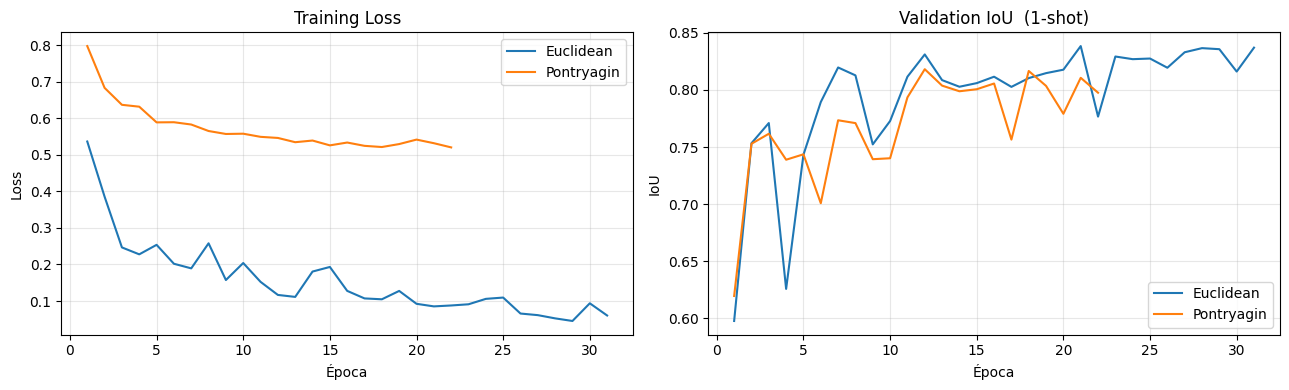

Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/curves_1shot.png


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for label, color in COLORS.items():
    csv_path = Path(DRIVE_RESULTS_ROOT) / run_dir(label) / 'metrics.csv'
    if not csv_path.exists():
        print(f'  {label}: metrics.csv not found — skipping'); continue
    df = pd.read_csv(csv_path)
    disp = label.replace('_', ' ').title()
    ax1.plot(df['epoch'], df['train_loss'], label=disp, color=color)
    ax2.plot(df['epoch'], df['val_iou'],    label=disp, color=color)

for ax, title, ylabel in [
    (ax1, 'Training Loss', 'Loss'),
    (ax2, f'Validation IoU  ({K_SHOT}-shot)', 'IoU'),
]:
    ax.set_title(title, fontsize=12); ax.set_xlabel('Época')
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
out = Path(DRIVE_RESULTS_ROOT) / f'curves_{K_SHOT}shot.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out}')

### 8c · Evaluación estadística sobre test

Corre 200 episodios de test, acumula métricas por episodio y aplica un Welch t-test.  
Las figuras se guardan en Drive.

In [12]:
import torch, numpy as np, json
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from prfe.data.fss_dataset import EpisodicUAVDataset
from run_fss_sugarcane import build_model
import configs.fss_sugarcane as cfg

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(DEVICE)
N_TEST = 200
THRESH = 0.5

# ── carga modelos ─────────────────────────────────────────────────────────────
models = {}
for label, run_cfg in RUNS.items():
    rdir = run_dir(label)
    ckpt = Path(DRIVE_RESULTS_ROOT) / rdir / 'best_model.pth'
    if not ckpt.exists():
        print(f'\u2717  {label}: checkpoint not found — skipping'); continue
    hpo_json = Path(DRIVE_RESULTS_ROOT) / rdir / 'hpo' / 'best_params.json'
    best_p = None
    if hpo_json.exists():
        best_p = {k: v for k, v in json.loads(hpo_json.read_text()).items()
                  if not k.startswith('_')}
    m, _ = build_model(run_cfg['model_type'], K_SHOT, device, params=best_p,
                       trainable_rff=run_cfg['trainable_rff'])
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval(); models[label] = m
    print(f'\u2713  {label}: loaded ({ckpt.stat().st_size/1024**2:.1f} MB)')

assert models, 'No models loaded — train first (section 7)'

# ── evaluación por episodio ───────────────────────────────────────────────────
test_ds     = EpisodicUAVDataset(DATA, 'test', k_shot=K_SHOT,
                                  n_episodes=N_TEST, img_size=cfg.IMG_SIZE, seed=42)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=2, pin_memory=True)

def _metrics(pred, gt):
    pred = (pred > THRESH).float()
    tp   = (pred * gt).sum(dim=(1,2))
    fp   = (pred * (1-gt)).sum(dim=(1,2))
    fn   = ((1-pred) * gt).sum(dim=(1,2))
    eps  = 1e-6
    return ((tp/(tp+fp+fn+eps)).cpu().numpy(),
            (2*tp/(2*tp+fp+fn+eps)).cpu().numpy(),
            (tp/(tp+fp+eps)).cpu().numpy(),
            (tp/(tp+fn+eps)).cpu().numpy())

all_m = {label: {'iou':[], 'dice':[], 'precision':[], 'recall':[]} for label in models}

for batch in tqdm(test_loader, desc='Test episodes'):
    si = batch['support_imgs'].to(device)
    sm = batch['support_masks'].to(device)
    qi = batch['query_img'].to(device)
    gt = batch['query_mask'].to(device)
    for label, model in models.items():
        with torch.no_grad():
            logits = model(si, sm, qi)
        for key, arr in zip(['iou','dice','precision','recall'], _metrics(logits, gt)):
            all_m[label][key].extend(arr)

for label in all_m:
    for k in all_m[label]:
        all_m[label][k] = np.array(all_m[label][k])

print(f'\nEvaluación completada  ({N_TEST} episodios, umbral={THRESH})')
for label, m in all_m.items():
    print(f'\n  {label}')
    for metric, vals in m.items():
        print(f'    {metric:10s}: {vals.mean():.4f} ± {vals.std():.4f}')

/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_16886/3869940964.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

✓  euclidean: loaded (7.5 MB)
✓  pontryagin: loaded (7.5 MB)


Test episodes: 100%|██████████| 50/50 [00:20<00:00,  2.39it/s]


Evaluación completada  (200 episodios, umbral=0.5)

  euclidean
    iou       : 0.7617 ± 0.1166
    dice      : 0.8596 ± 0.0780
    precision : 0.8871 ± 0.0642
    recall    : 0.8476 ± 0.1311

  pontryagin
    iou       : 0.7710 ± 0.1229
    dice      : 0.8651 ± 0.0802
    precision : 0.8091 ± 0.1149
    recall    : 0.9438 ± 0.0766


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats as scipy_stats
from itertools import combinations
import pandas as pd

METRICS = ['iou', 'dice', 'precision', 'recall']
LABELS  = {'iou': 'IoU', 'dice': 'Dice', 'precision': 'Precision', 'recall': 'Recall'}

# ── tabla estadística ─────────────────────────────────────────────────────────
rows = []
for label, m in all_m.items():
    row = {'Modelo': label}
    for met in METRICS:
        row[f'{LABELS[met]} mean'] = f"{m[met].mean():.4f}"
        row[f'{LABELS[met]} std']  = f"{m[met].std():.4f}"
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

# ── Welch t-test (pairwise) ────────────────────────────────────────────────────
mts = list(all_m.keys())
print('\nWelch t-test (pairwise):')
for (la, lb) in combinations(mts, 2):
    print(f'\n  {la}  vs  {lb}:')
    for met in METRICS:
        a, b = all_m[la][met], all_m[lb][met]
        t, p = scipy_stats.ttest_ind(a, b, equal_var=False)
        sig  = '**p<0.01**' if p < 0.01 else ('*p<0.05*' if p < 0.05 else 'n.s.')
        print(f'    {LABELS[met]:12s}: t={t:+.3f}  p={p:.4f}  {sig}'
              f'  \u0394={b.mean()-a.mean():+.4f}')

# ── figura: histogramas + boxplots ────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

for col, met in enumerate(METRICS):
    ax_hist = fig.add_subplot(gs[0, col])
    for label, color in COLORS.items():
        if label not in all_m: continue
        vals = all_m[label][met]
        disp = label.replace('_', ' ').title()
        ax_hist.hist(vals, bins=25, alpha=0.55, color=color,
                     label=disp, density=True)
        ax_hist.axvline(vals.mean(), color=color, lw=2, ls='--')
    ax_hist.set_title(LABELS[met], fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('Valor por episodio')
    if col == 0: ax_hist.set_ylabel('Densidad'); ax_hist.legend(fontsize=9)
    ax_hist.grid(alpha=0.25)

    ax_box = fig.add_subplot(gs[1, col])
    bp = ax_box.boxplot([all_m[label][met] for label in all_m],
                        patch_artist=True, widths=0.5,
                        medianprops=dict(color='white', lw=2))
    for patch, label in zip(bp['boxes'], all_m):
        patch.set_facecolor(COLORS.get(label, 'gray')); patch.set_alpha(0.75)
    ax_box.set_xticklabels([lb.replace('_', '\n') for lb in all_m], fontsize=8)
    ax_box.set_title(f'{LABELS[met]} — boxplot', fontsize=10)
    if col == 0: ax_box.set_ylabel(LABELS[met])
    ax_box.grid(axis='y', alpha=0.25)

title_str = ' vs '.join(lb.replace('_', ' ').title() for lb in all_m)
fig.suptitle(f'{title_str} — {N_TEST} episodios test  ({K_SHOT}-shot)',
             fontsize=11, y=1.01)
out_fig = Path(DRIVE_RESULTS_ROOT) / f'test_analysis_{K_SHOT}shot.png'
plt.savefig(out_fig, dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_fig}')

# ── JSON detallado ────────────────────────────────────────────────────────────
summary = {}
for label, m in all_m.items():
    summary[label] = {
        met: {'mean': float(m[met].mean()), 'std':  float(m[met].std()),
              'min':  float(m[met].min()),  'max':  float(m[met].max()),
              'median': float(np.median(m[met]))}
        for met in METRICS
    }
    summary[label]['n_episodes'] = int(len(m['iou']))
out_json = Path(DRIVE_RESULTS_ROOT) / f'test_detailed_{K_SHOT}shot.json'
out_json.write_text(json.dumps(summary, indent=2))
print(f'Guardado: {out_json}')

    Modelo IoU mean IoU std Dice mean Dice std Precision mean Precision std Recall mean Recall std
 euclidean   0.7617  0.1166    0.8596   0.0780         0.8871        0.0642      0.8476     0.1311
pontryagin   0.7710  0.1229    0.8651   0.0802         0.8091        0.1149      0.9438     0.0766

Welch t-test (pairwise):

  euclidean  vs  pontryagin:
    IoU         : t=-0.770  p=0.4420  n.s.  Δ=+0.0092
    Dice        : t=-0.696  p=0.4866  n.s.  Δ=+0.0055
    Precision   : t=+8.355  p=0.0000  **p<0.01**  Δ=-0.0780
    Recall      : t=-8.937  p=0.0000  **p<0.01**  Δ=+0.0962
Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/test_analysis_1shot.png
Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/test_detailed_1shot.json


/tmp/ipykernel_16886/1565273102.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 8d · Comparación visual

In [14]:
import torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from prfe.data.fss_dataset import EpisodicUAVDataset
import configs.fss_sugarcane as cfg

N_VIZ  = 6
viz_ds = EpisodicUAVDataset(DATA, 'test', k_shot=K_SHOT,
                             n_episodes=N_VIZ, img_size=cfg.IMG_SIZE, seed=123)

_MEAN  = np.array([0.485, 0.456, 0.406])
_STD   = np.array([0.229, 0.224, 0.225])
denorm = lambda t: np.clip(t.permute(1,2,0).cpu().numpy() * _STD + _MEAN, 0, 1)

n_col      = K_SHOT + 2 + len(models)
col_titles = ([f'Soporte {k+1}' for k in range(K_SHOT)]
              + ['Query', 'GT']
              + [f'Pred\n{mt.capitalize()}' for mt in models])

fig, axes = plt.subplots(N_VIZ, n_col, figsize=(3.0*n_col, 3.0*N_VIZ))
if N_VIZ == 1: axes = axes[None]

# Use range(N_VIZ) to guarantee we never exceed the figure rows.
for ei in range(N_VIZ):
    ep = viz_ds[ei]
    si = ep['support_imgs'].unsqueeze(0).to(device)
    sm = ep['support_masks'].unsqueeze(0).to(device)
    qi = ep['query_img'].unsqueeze(0).to(device)

    for k in range(K_SHOT):
        axes[ei, k].imshow(denorm(ep['support_imgs'][k]))
        mask_k  = ep['support_masks'][k].numpy()
        overlay = np.zeros((*mask_k.shape, 4))
        overlay[..., 1] = 0.8 * mask_k; overlay[..., 3] = 0.4 * mask_k
        axes[ei, k].imshow(overlay); axes[ei, k].axis('off')

    axes[ei, K_SHOT].imshow(denorm(ep['query_img']));             axes[ei, K_SHOT].axis('off')
    axes[ei, K_SHOT+1].imshow(ep['query_mask'].numpy(),
                               cmap='Greens', vmin=0, vmax=1);    axes[ei, K_SHOT+1].axis('off')

    for ci, (mt, model) in enumerate(models.items()):
        with torch.no_grad():
            pred = model.predict(si, sm, qi).squeeze(0).cpu().numpy()
        gt    = ep['query_mask'].numpy()
        iou_e = (pred*gt).sum() / (pred+gt-pred*gt).sum().clip(min=1e-6)
        ax    = axes[ei, K_SHOT+2+ci]
        ax.imshow(pred, cmap='Greens', vmin=0, vmax=1)
        ax.set_title(f'IoU={iou_e:.3f}', fontsize=8, pad=2)
        ax.axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=9, fontweight='bold', pad=6)

plt.suptitle(f'Predicciones {K_SHOT}-shot — Caña de azúcar  (verde = foreground)',
             fontsize=12, y=1.01)
plt.tight_layout()
out = Path(DRIVE_RESULTS_ROOT) / f'qualitative_{K_SHOT}shot.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Guardado: {out}')


Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/qualitative_1shot.png


/tmp/ipykernel_16886/1474782100.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 8e · Interpretabilidad — ScoreCAM · MC Dropout · Energía de embedding

Compara lo que "ve" el modelo **Euclidean** vs **Pontryagin** a través de:

- **ScoreCAM**: regiones de la query que activan la similitud con el prototipo  
- **MC Dropout**: varianza predictiva por pixel (T=30 pases estocásticos)  
- **Energía de embedding** (Pontryagin): ‖φ₊‖² (RFF) y ‖φ₋‖² (SRF)  
- **Métricas CAM**: GT-IoU, GT-Pearson (binarización Otsu) y *confidence-gain*

In [19]:
import subprocess, sys, shutil
from pathlib import Path

INTERP_DIR   = Path(DRIVE_RESULTS_ROOT) / f'interpretability_{K_SHOT}shot'
N_VIZ_INTERP = 20
N_MC_PASSES  = 50
FORCE_RERUN  = True   # ← cambia a False para saltar si ya existen resultados

if (INTERP_DIR / 'metrics.csv').exists() and not FORCE_RERUN:
    print(f'Resultados ya existen en {INTERP_DIR} (FORCE_RERUN=False)')
else:
    if INTERP_DIR.exists():
        shutil.rmtree(INTERP_DIR)
        print(f'Directorio previo borrado: {INTERP_DIR}')
    INTERP_DIR.mkdir(parents=True, exist_ok=True)
    print('Ejecutando análisis ScoreCAM …')
    res = subprocess.run(
        [sys.executable,
         f'{REPO_DIR}/experiments/interpretability_fss.py',
         '--k-shot',       str(K_SHOT),
         '--n-viz',        str(N_VIZ_INTERP),
         '--n-mc',         str(N_MC_PASSES),
         '--data-root',    DATA_ROOT,
         '--results-dir',  DRIVE_RESULTS_ROOT,
         '--device',       DEVICE,
        ],
        capture_output=False,
    )
    if res.returncode != 0:
        print('ERROR: ver stderr arriba.')
    else:
        print('Análisis ScoreCAM completado.')


Directorio previo borrado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/interpretability_1shot
Ejecutando análisis ScoreCAM …

Loading models (k_shot=1, trainable_rff=False) …
Analysing 20/200 test episodes …


/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/interpretability_fss.py:155: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.lo

  Episode  20/20


/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/interpretability_fss.py:757: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/interpretability_fss.py:757: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/interpretability_fss.py:757: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/interpretability_fss.py:757: MatplotlibDeprecationWarning: The 'labels' param


────────────────────────────────────────────────────────────
Summary over 20 episodes (1-shot FSS):
  Prediction IoU   — Euc: 0.7516±0.1395  Pont: 0.7193±0.1452
  MC variance      — Euc: 0.0004  Pont: 0.0012
  ScoreCAM GT-IoU  — Euc: 0.4787  Pont: 0.7608
  ScoreCAM Pearson — Euc: 0.7134   Pont: 0.8597
  Conf gain (mean) — Euc: -83.44%  Pont: -1.26%
  Pearson unc/E+   : nan
  Pearson unc/E-   : 0.3534
────────────────────────────────────────────────────────────
Results saved to /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/interpretability_1shot
Análisis ScoreCAM completado.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

INTERP_DIR = Path(DRIVE_RESULTS_ROOT) / f'interpretability_{K_SHOT}shot'
CSV = INTERP_DIR / 'metrics.csv'

if not CSV.exists():
    print('Ejecuta primero la celda de análisis.'); raise SystemExit

df = pd.read_csv(CSV)
ep = df['episode'].values
C_EUC  = '#1f77b4'   # blue
C_PONT = '#ff7f0e'   # orange
w = 0.35

# ── Resumen numérico ──────────────────────────────────────────────────────────
SHOW = {
    'iou_euclidean':        'Pred IoU (Euc)',
    'iou_pontryagin':       'Pred IoU (Pont)',
    'cam_euc_gt_iou':       'CAM GT-IoU (Euc)',
    'cam_pont_gt_iou':      'CAM GT-IoU (Pont)',
    'cam_euc_gt_pearson':   'CAM Pearson (Euc)',
    'cam_pont_gt_pearson':  'CAM Pearson (Pont)',
    'conf_gain_euc_mean':   'Conf gain % (Euc)',
    'conf_gain_pont_mean':  'Conf gain % (Pont)',
    'mc_var_euc_mean':      'MC variance (Euc)',
    'mc_var_pont_mean':     'MC variance (Pont)',
    'pearson_cam_e_cam_p':  'Pearson(CAM_E, CAM_P)',
}
print('=== Interpretability metrics summary ===')
for col, label in SHOW.items():
    if col in df.columns:
        v = df[col].dropna()
        print(f'  {label:30s}: {v.mean():+.4f} ± {v.std():.4f}')

# ── Figura 1: IoU + MC variance + CAM GT-IoU + Conf-gain ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

pairs = [
    ('iou_euclidean',      'iou_pontryagin',      'Pred IoU',              None),
    ('mc_var_euc_mean',    'mc_var_pont_mean',    'MC Dropout variance',   None),
    ('cam_euc_gt_iou',     'cam_pont_gt_iou',     'ScoreCAM GT-IoU',       None),
    ('conf_gain_euc_mean', 'conf_gain_pont_mean', 'Confidence gain (%)',   0.0),
]
for ax, (ke, kp, title, hline) in zip(axes, pairs):
    ax.bar(ep - w/2, df[ke], width=w, label='Euclidean',  alpha=0.8, color=C_EUC)
    ax.bar(ep + w/2, df[kp], width=w, label='Pontryagin', alpha=0.8, color=C_PONT)
    ax.axhline(df[ke].mean(), color=C_EUC,  ls='--', lw=1.2)
    ax.axhline(df[kp].mean(), color=C_PONT, ls='--', lw=1.2)
    if hline is not None:
        ax.axhline(hline, color='gray', ls=':', lw=1)
    mean_str = f'Euc={df[ke].mean():.3f}  Pont={df[kp].mean():.3f}'
    ax.set_title(f'{title}\n{mean_str}', fontsize=9)
    ax.set_xlabel('Episode')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'Interpretability — {K_SHOT}-shot FSS  (Euclidean vs Pontryagin)',
             fontsize=12, y=1.02)
plt.tight_layout()
out1 = INTERP_DIR / 'interp_overview.png'
plt.savefig(out1, dpi=130, bbox_inches='tight')
plt.show(); print(f'Guardado: {out1}')

# ── Figura 2: Scatter MC variance vs embedding energy ─────────────────────────
if {'energy_pos_mean','energy_neg_mean','mc_var_pont_mean'}.issubset(df.columns):
    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5))
    def _pearson(a, b):
        m = ~(np.isnan(a) | np.isnan(b))
        if m.sum() < 3: return float('nan')
        return float(np.corrcoef(a[m], b[m])[0, 1])

    for ax, ecol, elabel in [
        (axes2[0], 'energy_pos_mean', r'$\|\varphi_+\|^2$ (RFF)'),
        (axes2[1], 'energy_neg_mean', r'$\|\varphi_-\|^2$ (SRF)'),
    ]:
        x = df[ecol].values
        y = df['mc_var_pont_mean'].values
        c = df['iou_pontryagin'].values
        sc = ax.scatter(x, y, c=c, cmap='RdYlGn', alpha=0.75,
                        s=50, edgecolors='k', linewidths=0.4)
        r = _pearson(x, y)
        ax.annotate(f'r = {r:.3f}', xy=(0.97, 0.05), xycoords='axes fraction',
                    ha='right', fontsize=10)
        ax.set_xlabel(elabel, fontsize=10)
        ax.set_ylabel(f'MC Dropout variance (Pontryagin)', fontsize=9)
        ax.set_title(f'Uncertainty vs {elabel}')
        plt.colorbar(sc, ax=ax, label='Pontryagin IoU')

    plt.suptitle(f'MC uncertainty vs Pontryagin embedding energy — {K_SHOT}-shot',
                 fontsize=11)
    plt.tight_layout()
    out2 = INTERP_DIR / 'scatter_unc_vs_energy.png'
    plt.savefig(out2, dpi=130, bbox_inches='tight')
    plt.show(); print(f'Guardado: {out2}')

# ── Figura 3: CAM quality boxplots ────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 4, figsize=(18, 4.5))
cam_pairs = [
    ('cam_euc_gt_iou',       'cam_pont_gt_iou',       'GT IoU'),
    ('cam_euc_gt_recall',    'cam_pont_gt_recall',    'GT Recall'),
    ('cam_euc_gt_precision', 'cam_pont_gt_precision', 'GT Precision'),
    ('cam_euc_gt_pearson',   'cam_pont_gt_pearson',   'GT Pearson r'),
]
for ax, (ke, kp, label) in zip(axes3, cam_pairs):
    ve = df[ke].dropna().values
    vp = df[kp].dropna().values
    valid = min(len(ve), len(vp))
    if valid > 0:
        bp = ax.boxplot([ve, vp], labels=['Euclidean', 'Pontryagin'],
                        patch_artist=True,
                        medianprops=dict(color='white', lw=2))
        bp['boxes'][0].set_facecolor(C_EUC);  bp['boxes'][0].set_alpha(0.75)
        bp['boxes'][1].set_facecolor(C_PONT); bp['boxes'][1].set_alpha(0.75)
        ax.set_title(f'{label}\nEuc={ve.mean():.3f}  Pont={vp.mean():.3f}', fontsize=9)
    ax.set_ylabel(label, fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'ScoreCAM quality vs GT — {K_SHOT}-shot FSS', fontsize=11)
plt.tight_layout()
out3 = INTERP_DIR / 'cam_metrics.png'
plt.savefig(out3, dpi=130, bbox_inches='tight')
plt.show(); print(f'Guardado: {out3}')

=== Interpretability metrics summary ===
  Pred IoU (Euc)                : +0.7516 ± 0.1431
  Pred IoU (Pont)               : +0.7193 ± 0.1490
  CAM GT-IoU (Euc)              : +0.4787 ± 0.1843
  CAM GT-IoU (Pont)             : +0.7608 ± 0.1272
  CAM Pearson (Euc)             : +0.7134 ± 0.1154
  CAM Pearson (Pont)            : +0.8597 ± 0.0731
  Conf gain % (Euc)             : -83.4387 ± 12.4025
  Conf gain % (Pont)            : -1.2605 ± 4.9691
  MC variance (Euc)             : +0.0004 ± 0.0002
  MC variance (Pont)            : +0.0012 ± 0.0003
  Pearson(CAM_E, CAM_P)         : +0.6758 ± 0.0896


/tmp/ipykernel_16886/3163907897.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show(); print(f'Guardado: {out1}')
/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/interpretability_1shot/interp_overview.png


/tmp/ipykernel_16886/3163907897.py:96: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show(); print(f'Guardado: {out2}')
/tmp/ipykernel_16886/3163907897.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([ve, vp], labels=['Euclidean', 'Pontryagin'],
/tmp/ipykernel_16886/3163907897.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([ve, vp], labels=['Euclidean', 'Pontryagin'],
/tmp/ipykernel_16886/3163907897.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([ve, vp], labels=['Euclidean', 'Pontryagin'],
/tmp/ipykernel_16886/316390

Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/interpretability_1shot/scatter_unc_vs_energy.png
Guardado: /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane/interpretability_1shot/cam_metrics.png


/tmp/ipykernel_16886/3163907897.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show(); print(f'Guardado: {out3}')


## 9 · Descargar / explorar resultados

La copia en Drive ya es persistente. Esta celda permite descargar un zip a tu máquina local.

In [20]:
if IN_COLAB:
    import shutil
    from google.colab import files
    from pathlib import Path
    zip_path = '/content/fss_sugarcane_results'
    shutil.make_archive(zip_path, 'zip', DRIVE_RESULTS_ROOT)
    size_mb = Path(zip_path + '.zip').stat().st_size / 1e6
    print(f'Archive: {zip_path}.zip  ({size_mb:.1f} MB)')
    files.download(zip_path + '.zip')
else:
    print(f'Local mode — results are at:\n  {DRIVE_RESULTS_ROOT}')

Local mode — results are at:
  /home/craljimenez/Documents/PhD/003_pontriagyn_embebbed/experiments/results/fss_sugarcane


In [ ]:
# Explorar árbol de archivos en Drive
import os
for root, dirs, fnames in os.walk(DRIVE_RESULTS_ROOT):
    level  = root.replace(DRIVE_RESULTS_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in sorted(fnames):
            size = os.path.getsize(os.path.join(root, f)) / 1024
            print(f'{indent}  {f:<45} {size:7.1f} KB')